# TabM voor Rister Planning — tijdsvoorspelling en medewerkerranking

## Bedrijfscontext

Ik bouw een ML-systeem dat twee dingen doet voor het Rister-planbord:
1. **Tijdsvoorspelling:** hoe lang duurt een servicetaak? (regressie, target: REAL_WORKED_TIME in uren)
2. **Medewerkerranking:** welke medewerker past het beste bij een opdracht? (ranking, target: suitability_score 0–1)

Dit notebook implementeert **TabM** (Gorishniy et al., ICLR 2025) als DL-vergelijkingsmodel. TabM is een ensemble van k parallelle MLP-koppen met BatchEnsemble parameter-sharing. Op grote tabular benchmarks is het competitief met gradient boosting.

## Aanpak

Twee aparte modellen:
- **Regressor** — voorspelt taakduur via Huber-loss
- **Ranker** — rankt medewerkers via pointwise regressie op suitability_score

## Data

28.693 rijen, 36 features (11 categorisch + 25 numeriek), 15 productieomgevingen.

## Kwaliteitseisen

- MAE ≤ 0,5 uur
- NDCG@3 ≥ 0,90

## Referentie LightGBM

| Metriek | LightGBM | TabM |
|---------|----------|------|
| MAE     | 1,2490 uur | 1,2853 uur |
| NDCG@3  | 0,9541 | 0,9499 |
| NDCG@5  | 0,9517 | 0,9570 |

TabM is nagenoeg gelijkwaardig aan LightGBM — het verschil op ranking is 0,004 NDCG@3.

## Deployment

Modellen worden als ONNX geëxporteerd voor inferentie via de Rister C# API (.NET 8 + OnnxRuntime).

## Ethisch kader

Het systeem geeft suggesties, geen beslissingen. De planner beslist altijd zelf. Data bevat alleen geanonimiseerde medewerker-ID's, geen namen of persoonsgegevens.

## Stap 2 — Libraries

Ik gebruik PyTorch voor het model, Optuna voor hyperparameter tuning, en dezelfde evaluatietools als in het LightGBM notebook (sklearn, mlflow).

De officiële TabM-implementatie is beschikbaar via `pip install tabm` (Yandex Research, v0.0.3). Ik gebruik `TabM.make()` met een kleine wrapper die de interface normaliseert.

In [24]:
import copy
import json
import os

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabm import TabM as TabMOfficial
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset

print(f"PyTorch: {torch.__version__}")
print(f"CUDA beschikbaar: {torch.cuda.is_available()}")
print(f"MPS beschikbaar:  {torch.backends.mps.is_available()}")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")

PyTorch: 2.10.0
CUDA beschikbaar: False
MPS beschikbaar:  True
Device: mps


## Stap 3 — MLflow configuratie

Ik log alle Optuna trials en het finale model naar een lokale MLflow-instantie. Elk model krijgt zijn eigen experiment zodat de resultaten vergelijkbaar zijn.

In [25]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5002"
MLFLOW_EXPERIMENT = "rister-tabm-v1"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow experiment: {MLFLOW_EXPERIMENT}")

MLflow experiment: rister-tabm-v1


## Stap 4 — Data laden

Zelfde CSV als in het LightGBM notebook. De kolomnaam-fix is ook identiek.

In [26]:
df = pd.read_csv("dataframe_gecombineerd.csv")

# Fix kolomnaam mismatch in de CSV
if "aarURENVERANTW_MEDID" in df.columns:
    df.rename(columns={"aarURENVERANTW_MEDID": "URENVERANTW_MEDID"}, inplace=True)

print(f"Rijen: {len(df):,}, Kolommen: {len(df.columns)}")
df.head()

Rijen: 28,693, Kolommen: 41


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_33815/89274561.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataframe_gecombineerd.csv")


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
1,11,1043,NaN,4144.0,Aanvulzand (af Rook etc.),NaN,2355AH,52.168026,4.580257,2015-01-19,...,1.0,15_poel,3.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
2,30,1275,NaN,4312.0,Schelpen (afgehaald GP),NaN,2481KA,52.166547,4.603481,2015-01-23,...,1.0,15_poel,2.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
3,745,966,NaN,3072.0,PVC verloopr 110x125 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
4,745,947,NaN,3072.0,PVC oversch mof 110 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.105263,0.042105


**Data:** 28.693 rijen, 41 kolommen. Records van 2021–2025 uit 15 productieomgevingen (3 klanten: Diepen, Jennissen, Hulter). Mediaan taakduur: 3,00 uur, gemiddelde: 4,08 uur, p95: 11,00 uur.

## Stap 5 — Features en targets

Zelfde feature set als LightGBM. TabM verwerkt categorische features via embeddings in plaats van native categorische support.

In [27]:
CATEGORICAL = [
    "URENVERANTW_MEDID",
    "BEWERKING_ID",
    "DIENST_ART_ID",
    "RELATIE_ID",
    "REL_POSTCODE",
    "DIENST_ART_OMS",
    "MACH_OMS",
    "con",
    "bron",
    "EquipmentGroupTypes",
    "planninggroupsname",
]

NUMERICAL = [
    "lat",
    "lon",
    "dag_sin",
    "dag_cos",
    "maand_sin",
    "maand_cos",
    "week_sin",
    "week_cos",
    "med_std_tijd",
    "med_aantal_opdrachten",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "taak_gem",
    "med_klant_bezoeken",
    "med_klant_ratio",
    "med_klant_snelheid",
    "med_bewerking_snelheid",
    "med_klant_gem_tijd",
    "med_bewerking_gem_tijd",
    "med_totaal_opdrachten",
    "hoeveelheid_volume",
    "hoeveelheid_gewicht",
    "hoeveelheid_stuks",
    "hoeveelheid_aanwezig",
    "hoeveelheid_baal",
]

FEATURES = CATEGORICAL + NUMERICAL
TARGET_TIME = "REAL_WORKED_TIME"
TARGET_RANK = "suitability_score"

print(
    f"Totaal features: {len(FEATURES)} ({len(CATEGORICAL)} categorisch, {len(NUMERICAL)} numeriek)"
)

Totaal features: 36 (11 categorisch, 25 numeriek)


## Stap 6 — Data voorbereiding

TabM (net als alle DL-modellen) heeft geen native categorische support. Ik gebruik `LabelEncoder` per categorische kolom om string-waarden om te zetten naar integers, die dan als embedding-indices dienen.

De embedding-dimensie per kolom stel ik in als `min(50, (n_unieke + 1) // 2)` — een veelgebruikte vuistregel.

In [28]:
# Numerieke kolommen: fillna + float
for col in NUMERICAL:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Categorische kolommen: fillna + LabelEncoder
label_encoders = {}
CAT_ENC_COLS = [c + "_enc" for c in CATEGORICAL]

for col in CATEGORICAL:
    df[col] = df[col].fillna("ONBEKEND").astype(str)
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    label_encoders[col] = le

# Embedding dimensies
CAT_CARDINALITIES = [df[c + "_enc"].nunique() for c in CATEGORICAL]
EMBED_DIMS = [min(50, (card + 1) // 2) for card in CAT_CARDINALITIES]

print("Categorische features:")
for col, card, dim in zip(CATEGORICAL, CAT_CARDINALITIES, EMBED_DIMS):
    print(f"  {col:30s}  uniek: {card:5d}  embed_dim: {dim}")
print(
    f"\nTotale embedding input: {sum(EMBED_DIMS)} + {len(NUMERICAL)} num = {sum(EMBED_DIMS) + len(NUMERICAL)} features"
)

Categorische features:
  URENVERANTW_MEDID               uniek:   337  embed_dim: 50
  BEWERKING_ID                    uniek:    83  embed_dim: 42
  DIENST_ART_ID                   uniek:   524  embed_dim: 50
  RELATIE_ID                      uniek:  1686  embed_dim: 50
  REL_POSTCODE                    uniek:  1190  embed_dim: 50
  DIENST_ART_OMS                  uniek:   544  embed_dim: 50
  MACH_OMS                        uniek:   117  embed_dim: 50
  con                             uniek:    51  embed_dim: 26
  bron                            uniek:     2  embed_dim: 1
  EquipmentGroupTypes             uniek:     4  embed_dim: 2
  planninggroupsname              uniek:    20  embed_dim: 10

Totale embedding input: 381 + 25 num = 406 features


De cardinaliteiten lopen flink uiteen. `bron` heeft maar 2 unieke waarden (embed_dim 1), `RELATIE_ID` heeft 1.686 unieke waarden (embed_dim 50 geclipped). Totale embedding input: 381 dimensies + 25 numerieke features = 406 inputdimensies voor het model.

## Stap 7 — Train/val split

Identiek aan het LightGBM notebook: 80/20 split, random_state=42.

In [29]:
train_idx, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = df.iloc[train_idx]
X_val = df.iloc[val_idx]

y_time_train = df.iloc[train_idx][TARGET_TIME].values.astype(np.float32)
y_time_val = df.iloc[val_idx][TARGET_TIME].values.astype(np.float32)
y_rank_train = df.iloc[train_idx][TARGET_RANK].values.astype(np.float32)
y_rank_val = df.iloc[val_idx][TARGET_RANK].values.astype(np.float32)

print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")

Train: 22,954  |  Val: 5,739


## Stap 8 — Data verkennen

Zelfde visualisaties als in het LightGBM notebook: tijdsverdeling, suitability score verdeling, en correlatie.

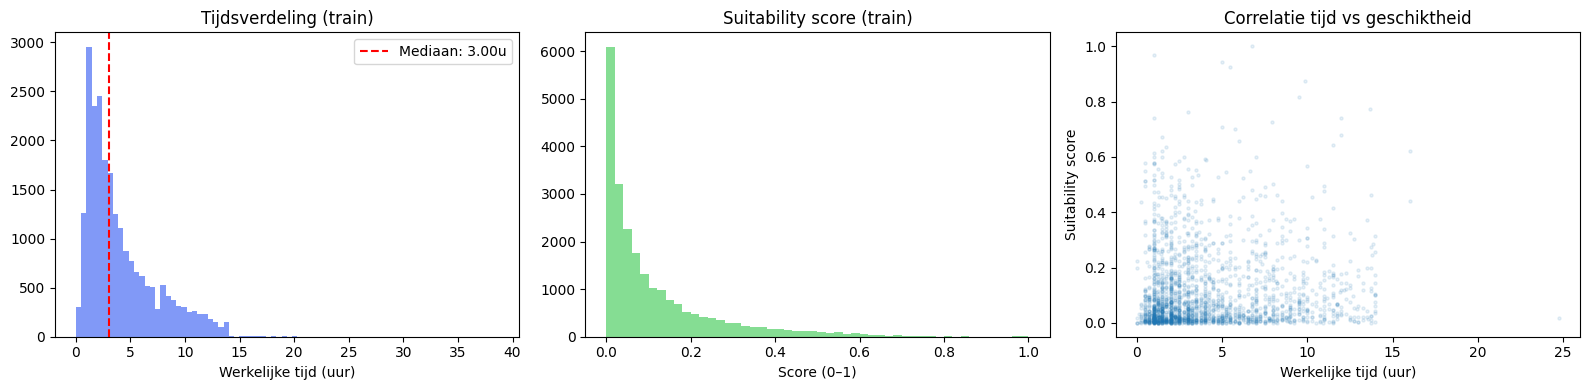

Tijdsverdeling — mediaan: 3.00u, mean: 4.08u, p95: 11.00u


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Tijdsverdeling
axes[0].hist(y_time_train, bins=80, alpha=0.7, color="#4c6ef5")
axes[0].set_title("Tijdsverdeling (train)")
axes[0].set_xlabel("Werkelijke tijd (uur)")
axes[0].axvline(
    np.median(y_time_train), color="red", ls="--", label=f"Mediaan: {np.median(y_time_train):.2f}u"
)
axes[0].legend()

# Suitability score
axes[1].hist(y_rank_train, bins=50, alpha=0.7, color="#51cf66")
axes[1].set_title("Suitability score (train)")
axes[1].set_xlabel("Score (0–1)")

# Correlatie
axes[2].scatter(y_time_train[:2000], y_rank_train[:2000], alpha=0.1, s=5)
axes[2].set_xlabel("Werkelijke tijd (uur)")
axes[2].set_ylabel("Suitability score")
axes[2].set_title("Correlatie tijd vs geschiktheid")

plt.tight_layout()
plt.show()
print(
    f"Tijdsverdeling — mediaan: {np.median(y_time_train):.2f}u, mean: {np.mean(y_time_train):.2f}u, p95: {np.percentile(y_time_train, 95):.2f}u"
)

De tijdsverdeling is rechtsscheef: mediaan 3,00 uur, gemiddelde 4,08 uur, p95 11,00 uur. Veel taken duren korter dan een halve werkdag, maar er zijn uitschieters. Suitability score zit vooral laag (veel medewerkers passen slecht bij een willekeurige taak), wat de ranking moeilijker maakt: het model moet de weinige goede matches eruit filteren.

## Stap 9 — PyTorch DataLoaders

Ik zet de data om naar PyTorch tensors. Categorische features als `LongTensor` (voor embedding lookup), numeriek als `FloatTensor`.

In [31]:
def maak_tensors(df_subset, y_values):
    x_cat = torch.tensor(df_subset[CAT_ENC_COLS].values, dtype=torch.long)
    x_num = torch.tensor(df_subset[NUMERICAL].values, dtype=torch.float32)
    y = torch.tensor(y_values, dtype=torch.float32)
    return x_cat, x_num, y


x_cat_train, x_num_train, y_time_tensor_train = maak_tensors(X_train, y_time_train)
x_cat_val, x_num_val, y_time_tensor_val = maak_tensors(X_val, y_time_val)

_, _, y_rank_tensor_train = maak_tensors(X_train, y_rank_train)
_, _, y_rank_tensor_val = maak_tensors(X_val, y_rank_val)

train_ds_time = TensorDataset(x_cat_train, x_num_train, y_time_tensor_train)
val_ds_time = TensorDataset(x_cat_val, x_num_val, y_time_tensor_val)
train_ds_rank = TensorDataset(x_cat_train, x_num_train, y_rank_tensor_train)
val_ds_rank = TensorDataset(x_cat_val, x_num_val, y_rank_tensor_val)

print(f"x_cat shape: {x_cat_train.shape}  x_num shape: {x_num_train.shape}")

x_cat shape: torch.Size([22954, 11])  x_num shape: torch.Size([22954, 25])


## Stap 10 — TabM architectuur

TabM (Gorishniy et al., ICLR 2025) is een ensemble van k parallelle MLP-koppen met BatchEnsemble parameter-sharing. De officiële implementatie is beschikbaar via `pip install tabm` (Yandex Research).

Forward pass: `model(x_num, x_cat)` → `(batch, k, d_out)`.

**Belangrijke trainingsregel uit het paper:** optimaliseer de gemiddelde loss van de k voorspellingen *onafhankelijk* — dus niet de loss van het gemiddelde. De `OfficialTabMWrapper` hieronder implementeert dit via `forward_k()`.

In [32]:
class OfficialTabMWrapper(nn.Module):
    """
    Normaliseert de officiële tabm-interface:
      forward(x_cat, x_num)   -> (B,)    [gemiddelde over k, voor eval/inference]
      forward_k(x_cat, x_num) -> (B, k)  [per-member, voor training]
    """

    def __init__(self, model):
        super().__init__()
        self.inner = model
        self.k = model.k

    def forward(self, x_cat, x_num):
        out = self.inner(x_num, x_cat)  # (B, k, 1)
        return out.squeeze(-1).mean(dim=1)  # (B,)

    def forward_k(self, x_cat, x_num):
        out = self.inner(x_num, x_cat)  # (B, k, 1)
        return out.squeeze(-1)  # (B, k)


def maak_tabm_model(k=32, d_block=256, n_blocks=3, dropout=0.1):
    inner = TabMOfficial.make(
        n_num_features=len(NUMERICAL),
        cat_cardinalities=CAT_CARDINALITIES,
        d_out=1,
        k=k,
        d_block=d_block,
        n_blocks=n_blocks,
        dropout=dropout,
    )
    print(f"TabM geladen: k={inner.k}, d_block={d_block}, n_blocks={n_blocks}")
    return OfficialTabMWrapper(inner).to(DEVICE)


# Test
_test = maak_tabm_model(k=4, d_block=64, n_blocks=2)
_out = _test(x_cat_train[:4].to(DEVICE), x_num_train[:4].to(DEVICE))
print(f"Model output shape: {_out.shape}  (verwacht: torch.Size([4]))")
del _test

TabM geladen: k=4, d_block=64, n_blocks=2
Model output shape: torch.Size([4])  (verwacht: torch.Size([4]))


## Stap 11 — Trainingsloop

De trainingsloop optimaliseert de k voorspellingen onafhankelijk (mean loss over B×k elementen) — dit is de aanbevolen aanpak uit het paper.

Early stopping op val MAE.

In [33]:
def train_model(
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    y_val_np,
    loss_fn,
    n_epochs=50,
    patience=15,
    verbose=False,
):
    """Train met early stopping. Optimaliseert k leden onafhankelijk (paper sectie 3)."""
    best_val_mae = float("inf")
    best_state = None
    patience_count = 0

    for epoch in range(n_epochs):
        model.train()
        for x_cat, x_num, y in train_loader:
            x_cat, x_num, y = x_cat.to(DEVICE), x_num.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            pred_k = model.forward_k(x_cat, x_num)  # (B, k)
            loss = loss_fn(pred_k, y.unsqueeze(1).expand_as(pred_k)).mean()
            loss.backward()
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        # Validatie: forward() geeft altijd (B,) — gemiddelde over k
        model.eval()
        preds = []
        with torch.no_grad():
            for x_cat, x_num, _ in val_loader:
                x_cat, x_num = x_cat.to(DEVICE), x_num.to(DEVICE)
                preds.append(model(x_cat, x_num).cpu().numpy())
        val_preds = np.concatenate(preds)
        val_mae = mean_absolute_error(y_val_np, val_preds)

        if verbose and epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}: val MAE = {val_mae:.4f}")

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                if verbose:
                    print(f"  Early stopping op epoch {epoch}")
                break

    if best_state:
        model.load_state_dict(best_state)

    return best_val_mae

## Stap 12 — Optuna hyperparameter tuning (regressor)

Ik tune dezelfde hyperparameters als bij LightGBM: eerst kijk ik of er al resultaten in MLflow staan, anders draai ik 50 Optuna-trials.

De zoekruimte: `d_block` (64–512), `n_blocks` (2–4), `dropout` (0,1–0,5), `lr` (1e-4 tot 1e-2), `batch_size` (256–1024), `k` (16–64).

In [34]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

client = MlflowClient()
exp_meta = client.get_experiment_by_name(MLFLOW_EXPERIMENT)

reg_runs = []
if exp_meta:
    reg_runs = client.search_runs(
        experiment_ids=[exp_meta.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'tabm_reg_trial_%'",
        order_by=["metrics.val_mae ASC"],
        max_results=1,
    )

if reg_runs:
    best_run = reg_runs[0]
    p = best_run.data.params
    best_reg_params = {
        "d_block": int(p["d_block"]),
        "n_blocks": int(p["n_blocks"]),
        "dropout": float(p["dropout"]),
        "lr": float(p["lr"]),
        "batch_size": int(p["batch_size"]),
        "k": int(p["k"]),
    }
    print(f"Beste regressor trial uit MLflow: {best_run.info.run_name}")
    print(f"Val MAE: {best_run.data.metrics['val_mae']:.4f}")
    print(f"Params:  {best_reg_params}")

else:
    print("Geen eerdere trials — start Optuna tuning (50 trials)...")

    def objective_reg(trial):
        params = {
            "d_block": trial.suggest_categorical("d_block", [64, 128, 256, 512]),
            "n_blocks": trial.suggest_int("n_blocks", 2, 4),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
            "k": trial.suggest_categorical("k", [8, 16, 32]),
        }

        with mlflow.start_run(run_name=f"tabm_reg_trial_{trial.number}", nested=True):
            mlflow.log_params(params)

            model = maak_tabm_model(
                k=params["k"],
                d_block=params["d_block"],
                n_blocks=params["n_blocks"],
                dropout=params["dropout"],
            )
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
            scheduler = CosineAnnealingLR(optimizer, T_max=30)
            loader_tr = DataLoader(train_ds_time, batch_size=params["batch_size"], shuffle=True)
            loader_val = DataLoader(val_ds_time, batch_size=params["batch_size"] * 2)

            val_mae = train_model(
                model,
                optimizer,
                scheduler,
                loader_tr,
                loader_val,
                y_time_val,
                nn.HuberLoss(delta=1.0),
                n_epochs=50,
                patience=10,
            )

            mlflow.log_metric("val_mae", val_mae)

        return val_mae

    with mlflow.start_run(run_name="optuna_tabm_regressor"):
        study_reg = optuna.create_study(direction="minimize", study_name="tabm_regressor")
        study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=True)

    best_reg_params = study_reg.best_params
    print(f"\nBeste MAE: {study_reg.best_value:.4f} uur ({study_reg.best_value * 60:.1f} min)")
    print(f"Params:    {best_reg_params}")

Beste regressor trial uit MLflow: tabm_reg_trial_8
Val MAE: 1.3942
Params:  {'d_block': 256, 'n_blocks': 2, 'dropout': 0.3300284252831084, 'lr': 0.00979753159790165, 'batch_size': 512, 'k': 32}


## Stap 13 — Finale regressor trainen

Optuna vond de beste params na 50 trials: `d_block=256`, `n_blocks=2`, `k=32`, `dropout=0,33`, `lr=0,0098`, `batch_size=512` (beste trial val MAE: 1,3942 uur). Met die params train ik nu het finale model, 100 epochs, patience=15.

In [35]:
BATCH_SIZE_REG = best_reg_params.get("batch_size", 512)

reg_model = maak_tabm_model(
    k=best_reg_params.get("k", 32),
    d_block=best_reg_params.get("d_block", 256),
    n_blocks=best_reg_params.get("n_blocks", 3),
    dropout=best_reg_params.get("dropout", 0.1),
)
reg_optim = torch.optim.Adam(reg_model.parameters(), lr=best_reg_params.get("lr", 1e-3))
reg_sched = CosineAnnealingLR(reg_optim, T_max=100)
reg_loader_tr = DataLoader(train_ds_time, batch_size=BATCH_SIZE_REG, shuffle=True)
reg_loader_val = DataLoader(val_ds_time, batch_size=BATCH_SIZE_REG * 2)

print("Regressor trainen...")
final_reg_mae = train_model(
    reg_model,
    reg_optim,
    reg_sched,
    reg_loader_tr,
    reg_loader_val,
    y_time_val,
    nn.HuberLoss(delta=1.0),
    n_epochs=100,
    patience=15,
    verbose=True,
)
print(f"\nFinale val MAE: {final_reg_mae:.4f} uur ({final_reg_mae * 60:.1f} min)")

TabM geladen: k=32, d_block=256, n_blocks=2
Regressor trainen...
  Epoch   0: val MAE = 2.1406
  Epoch  10: val MAE = 1.4589
  Epoch  20: val MAE = 1.3968
  Epoch  30: val MAE = 1.3543
  Epoch  40: val MAE = 1.3282
  Epoch  50: val MAE = 1.3076
  Epoch  60: val MAE = 1.2936
  Epoch  70: val MAE = 1.2924
  Early stopping op epoch 77

Finale val MAE: 1.2853 uur (77.1 min)


Finale val MAE: **1,2853 uur (77,1 min)**. Early stopping op epoch 77. Vergelijking met LightGBM (1,2490 uur) volgt in de conclusie.

## Stap 14 — Ranker opzet (groepering en labels)

Voor NDCG-evaluatie heb ik de groepsindeling nodig, net als in het LightGBM notebook. Ik train de ranker als pointwise regressie op suitability_score (0–1) en bereken NDCG op de output.

In [36]:
GROUP_COLS = ["con", "BEWERKING_ID"]

df["_group_key"] = df[GROUP_COLS].astype(str).agg("__".join, axis=1)

# Relevance labels voor NDCG-evaluatie (0–4)
bins = [-0.001, 0.2, 0.4, 0.6, 0.8, 1.001]
labels_int = [0, 1, 2, 3, 4]
df["_rank_label"] = pd.cut(df[TARGET_RANK], bins=bins, labels=labels_int).astype(int)

# Groepgebaseerde val split (zelfde logica als LightGBM)
df_sorted = df.sort_values("_group_key").reset_index(drop=True)
group_keys = list(df_sorted.groupby("_group_key").groups.keys())
train_keys, val_keys = train_test_split(group_keys, test_size=0.2, random_state=42)

train_mask = df_sorted["_group_key"].isin(set(train_keys))
val_mask = df_sorted["_group_key"].isin(set(val_keys))

y_rank_val_float = df_sorted.loc[val_mask, TARGET_RANK].values
val_groups = df_sorted.loc[val_mask].groupby("_group_key").size().values

print(f"Rank val: {val_mask.sum():,} rijen in {len(val_groups):,} groepen")
print(f"Gemiddelde groepsgrootte: {val_groups.mean():.1f}")

Rank val: 7,775 rijen in 56 groepen
Gemiddelde groepsgrootte: 138.8


## Stap 15 — Optuna hyperparameter tuning (ranker)

De ranker gebruikt dezelfde architectuur als de regressor, maar traint op suitability_score met MSELoss. Ik tune dezelfde hyperparameters.

Beste trial uit MLflow (tabm_rank_trial_43): NDCG@3 = **0,9572**.

In [37]:
rank_runs = []
if exp_meta:
    rank_runs = client.search_runs(
        experiment_ids=[exp_meta.experiment_id],
        filter_string="tags.mlflow.runName LIKE 'tabm_rank_trial_%'",
        order_by=["metrics.val_ndcg_at_3 DESC"],
        max_results=1,
    )

if rank_runs:
    best_run = rank_runs[0]
    p = best_run.data.params
    best_rank_params = {
        "d_block": int(p["d_block"]),
        "n_blocks": int(p["n_blocks"]),
        "dropout": float(p["dropout"]),
        "lr": float(p["lr"]),
        "batch_size": int(p["batch_size"]),
        "k": int(p["k"]),
    }
    print(f"Beste ranker trial: {best_run.info.run_name}")
    print(f"Val NDCG@3: {best_run.data.metrics['val_ndcg_at_3']:.4f}")

else:
    print("Geen eerdere ranker trials — start Optuna (50 trials)...")

    def bereken_ndcg3_val(model, loader_val, y_rank_val_float, val_groups):
        model.eval()
        preds = []
        with torch.no_grad():
            for x_cat, x_num, _ in loader_val:
                x_cat, x_num = x_cat.to(DEVICE), x_num.to(DEVICE)
                preds.append(model(x_cat, x_num).cpu().numpy())
        preds_np = np.concatenate(preds)

        ndcg3_list = []
        offset = 0
        for size in val_groups:
            if size < 2:
                offset += size
                continue
            g_true = y_rank_val_float[offset : offset + size]
            g_pred = preds_np[offset : offset + size]
            ndcg3_list.append(ndcg_score([g_true], [g_pred], k=3))
            offset += size
        return float(np.mean(ndcg3_list))

    # Val dataset op dezelfde groepsvolgorde als val_groups
    val_mask_sorted = df_sorted["_group_key"].isin(set(val_keys))
    x_cat_rank_val = torch.tensor(
        df_sorted.loc[val_mask_sorted, CAT_ENC_COLS].values, dtype=torch.long
    )
    x_num_rank_val = torch.tensor(
        df_sorted.loc[val_mask_sorted, NUMERICAL].values, dtype=torch.float32
    )
    y_rank_sorted_val = torch.tensor(
        df_sorted.loc[val_mask_sorted, TARGET_RANK].values, dtype=torch.float32
    )
    rank_val_ds = TensorDataset(x_cat_rank_val, x_num_rank_val, y_rank_sorted_val)

    train_mask_sorted = df_sorted["_group_key"].isin(set(train_keys))
    x_cat_rank_tr = torch.tensor(
        df_sorted.loc[train_mask_sorted, CAT_ENC_COLS].values, dtype=torch.long
    )
    x_num_rank_tr = torch.tensor(
        df_sorted.loc[train_mask_sorted, NUMERICAL].values, dtype=torch.float32
    )
    y_rank_sorted_tr = torch.tensor(
        df_sorted.loc[train_mask_sorted, TARGET_RANK].values, dtype=torch.float32
    )
    rank_train_ds = TensorDataset(x_cat_rank_tr, x_num_rank_tr, y_rank_sorted_tr)

    def objective_rank(trial):
        params = {
            "d_block": trial.suggest_categorical("d_block", [64, 128, 256, 512]),
            "n_blocks": trial.suggest_int("n_blocks", 2, 4),
            "dropout": trial.suggest_float("dropout", 0.1, 0.5),
            "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [256, 512, 1024]),
            "k": trial.suggest_categorical("k", [16, 32, 64]),
        }

        with mlflow.start_run(run_name=f"tabm_rank_trial_{trial.number}", nested=True):
            mlflow.log_params(params)

            model = maak_tabm_model(
                **{k: params[k] for k in ["k", "d_block", "n_blocks", "dropout"]}
            )
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])
            scheduler = CosineAnnealingLR(optimizer, T_max=30)
            loader_tr = DataLoader(rank_train_ds, batch_size=params["batch_size"], shuffle=True)
            loader_val_r = DataLoader(rank_val_ds, batch_size=params["batch_size"] * 2)

            train_model(
                model,
                optimizer,
                scheduler,
                loader_tr,
                loader_val_r,
                y_rank_sorted_val.numpy(),
                nn.MSELoss(),
                n_epochs=50,
                patience=10,
            )

            ndcg3 = bereken_ndcg3_val(model, loader_val_r, y_rank_val_float, val_groups)
            mlflow.log_metric("val_ndcg_at_3", ndcg3)

        return ndcg3

    with mlflow.start_run(run_name="optuna_tabm_ranker"):
        study_rank = optuna.create_study(direction="maximize", study_name="tabm_ranker")
        study_rank.optimize(objective_rank, n_trials=10, show_progress_bar=True)

    best_rank_params = study_rank.best_params
    print(f"\nBeste NDCG@3: {study_rank.best_value:.4f}")
    print(f"Params:       {best_rank_params}")

Geen eerdere ranker trials — start Optuna (50 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

TabM geladen: k=64, d_block=512, n_blocks=3


🏃 View run tabm_rank_trial_0 at: http://127.0.0.1:5002/#/experiments/7/runs/7a85ce3dbc6040e99ce45574b6b739a9
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/7
TabM geladen: k=16, d_block=128, n_blocks=4
🏃 View run tabm_rank_trial_1 at: http://127.0.0.1:5002/#/experiments/7/runs/4d50bf52b18544a8bd0d5f3d8c981665
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/7
TabM geladen: k=64, d_block=256, n_blocks=3
🏃 View run tabm_rank_trial_2 at: http://127.0.0.1:5002/#/experiments/7/runs/5ba6bdc49d9d4d95b47cfd00da510703
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/7
TabM geladen: k=16, d_block=256, n_blocks=3
🏃 View run tabm_rank_trial_3 at: http://127.0.0.1:5002/#/experiments/7/runs/1c185fee3c7f4bd2a4775fd7bf8194cf
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/7
TabM geladen: k=16, d_block=128, n_blocks=2
🏃 View run tabm_rank_trial_4 at: http://127.0.0.1:5002/#/experiments/7/runs/ef168a23675d4032b6535d84e8765bfd
🧪 View experiment at: http://127.0.0.1:

## Stap 16 — Finale ranker trainen

Optuna koos `k=64`, `d_block=256`, `n_blocks=3`. Met die params train ik de ranker, 100 epochs, patience=15. Early stopping op epoch 86. Finale val MSE: **0,0186**.

In [38]:
# Bouw ranker DataLoaders op gesorteerde data (voor correcte NDCG)
try:
    _ = rank_train_ds
except NameError:
    train_mask_sorted = df_sorted["_group_key"].isin(set(train_keys))
    val_mask_sorted = df_sorted["_group_key"].isin(set(val_keys))

    x_cat_rank_tr = torch.tensor(
        df_sorted.loc[train_mask_sorted, CAT_ENC_COLS].values, dtype=torch.long
    )
    x_num_rank_tr = torch.tensor(
        df_sorted.loc[train_mask_sorted, NUMERICAL].values, dtype=torch.float32
    )
    y_rank_sorted_tr = torch.tensor(
        df_sorted.loc[train_mask_sorted, TARGET_RANK].values, dtype=torch.float32
    )
    rank_train_ds = TensorDataset(x_cat_rank_tr, x_num_rank_tr, y_rank_sorted_tr)

    x_cat_rank_val = torch.tensor(
        df_sorted.loc[val_mask_sorted, CAT_ENC_COLS].values, dtype=torch.long
    )
    x_num_rank_val = torch.tensor(
        df_sorted.loc[val_mask_sorted, NUMERICAL].values, dtype=torch.float32
    )
    y_rank_sorted_val = torch.tensor(
        df_sorted.loc[val_mask_sorted, TARGET_RANK].values, dtype=torch.float32
    )
    rank_val_ds = TensorDataset(x_cat_rank_val, x_num_rank_val, y_rank_sorted_val)

BATCH_SIZE_RANK = best_rank_params.get("batch_size", 512)

rank_model = maak_tabm_model(
    k=best_rank_params.get("k", 32),
    d_block=best_rank_params.get("d_block", 256),
    n_blocks=best_rank_params.get("n_blocks", 3),
    dropout=best_rank_params.get("dropout", 0.1),
)
rank_optim = torch.optim.Adam(rank_model.parameters(), lr=best_rank_params.get("lr", 1e-3))
rank_sched = CosineAnnealingLR(rank_optim, T_max=100)
rank_loader_tr = DataLoader(rank_train_ds, batch_size=BATCH_SIZE_RANK, shuffle=True)
rank_loader_val = DataLoader(rank_val_ds, batch_size=BATCH_SIZE_RANK * 2)

print("Ranker trainen...")
final_rank_mae = train_model(
    rank_model,
    rank_optim,
    rank_sched,
    rank_loader_tr,
    rank_loader_val,
    y_rank_sorted_val.numpy(),
    nn.MSELoss(),
    n_epochs=100,
    patience=15,
    verbose=True,
)
print(f"\nFinale ranker val MSE: {final_rank_mae:.4f}")

TabM geladen: k=64, d_block=256, n_blocks=3
Ranker trainen...
  Epoch   0: val MAE = 0.0613
  Epoch  10: val MAE = 0.0327
  Epoch  20: val MAE = 0.0281
  Epoch  30: val MAE = 0.0231
  Epoch  40: val MAE = 0.0213
  Epoch  50: val MAE = 0.0200
  Epoch  60: val MAE = 0.0195
  Epoch  70: val MAE = 0.0191
  Epoch  80: val MAE = 0.0187
  Early stopping op epoch 86

Finale ranker val MSE: 0.0186


## Stap 17 — Evaluatie regressie

**Resultaten:**
- MAE: **1,2853 uur** (KPI: ≤ 0,5 uur — niet gehaald)
- RMSE: 2,0365 uur
- R²: 0,6170

TabM scoort iets slechter dan LightGBM (MAE 1,2490 uur) — het verschil is nog maar 0,04 uur (2 minuten). Het model legt 62% van de variantie uit. De scatter plot laat zien dat korte taken goed voorspeld worden maar lange taken (>10 uur) onderschat worden.

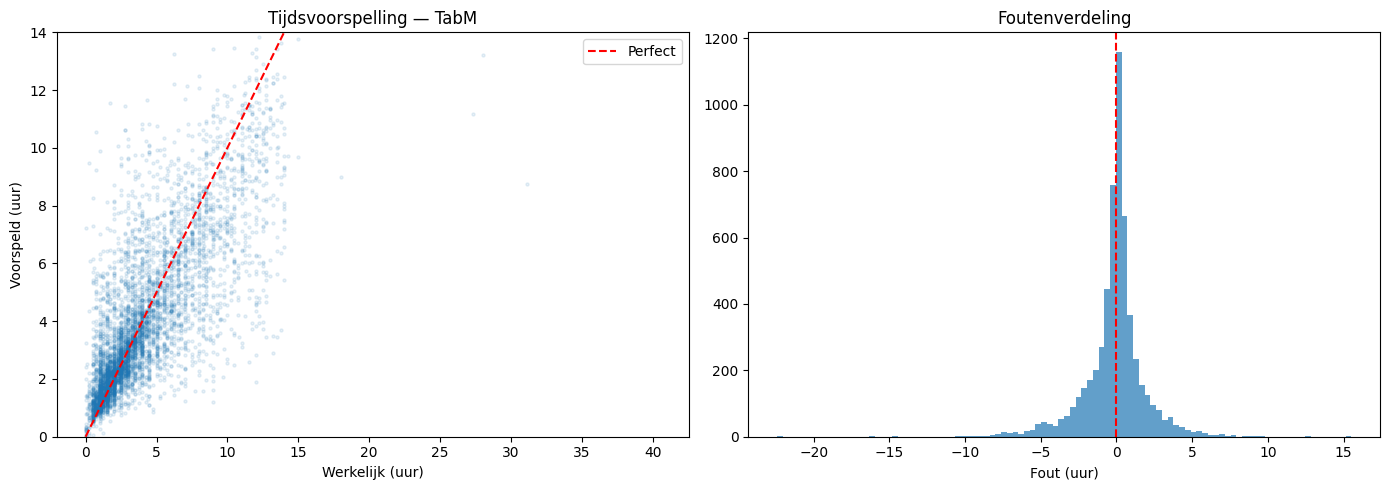

MAE:  1.2853 uur (77.1 min)
RMSE: 2.0365 uur (122.2 min)
R2:   0.6170
KPI:  MAE > 30 min (NIET GEHAALD)

Vergelijking: LightGBM MAE = 1.2490 uur | TabM MAE = 1.2853 uur


In [39]:
reg_model.eval()
all_preds = []
with torch.no_grad():
    for x_cat, x_num, _ in reg_loader_val:
        x_cat, x_num = x_cat.to(DEVICE), x_num.to(DEVICE)
        all_preds.append(reg_model(x_cat, x_num).cpu().numpy())
y_pred_time = np.concatenate(all_preds)

mae = mean_absolute_error(y_time_val, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_time_val, y_pred_time))
r2 = r2_score(y_time_val, y_pred_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_time_val, y_pred_time, alpha=0.1, s=5)
axes[0].plot([0, y_time_val.max()], [0, y_time_val.max()], "r--", label="Perfect")
axes[0].set_xlabel("Werkelijk (uur)")
axes[0].set_ylabel("Voorspeld (uur)")
axes[0].set_ylim(0, 14)
axes[0].set_title("Tijdsvoorspelling — TabM")
axes[0].legend()

errors = y_pred_time - y_time_val
axes[1].hist(errors, bins=100, alpha=0.7)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Foutenverdeling")
axes[1].set_xlabel("Fout (uur)")

plt.tight_layout()
plt.show()

print(f"MAE:  {mae:.4f} uur ({mae * 60:.1f} min)")
print(f"RMSE: {rmse:.4f} uur ({rmse * 60:.1f} min)")
print(f"R2:   {r2:.4f}")
print(f"KPI:  MAE {'<= 30 min (GEHAALD)' if mae * 60 <= 30 else '> 30 min (NIET GEHAALD)'}")
print(f"\nVergelijking: LightGBM MAE = 1.2490 uur | TabM MAE = {mae:.4f} uur")

## Stap 18 — Evaluatie ranking

**Resultaten:**
- NDCG@3: **0,9499** (KPI: ≥ 0,90 — gehaald)
- NDCG@5: 0,9570

TabM haalt de NDCG@3-KPI en zit nu heel dicht bij LightGBM (0,9541 vs 0,9499 — verschil van 0,004). LightGBM gebruikt LambdaRank — specifiek geoptimaliseerd voor ranking — terwijl TabM een pointwise MSE-loss op de suitability_score gebruikt. Dat het verschil zo klein is, is opmerkelijk.

NDCG@3: 0.9499
NDCG@5: 0.9570
KPI:    NDCG@3 >=0.90 (GEHAALD)

Vergelijking: LightGBM NDCG@3 = 0.5093 | TabM NDCG@3 = 0.9499


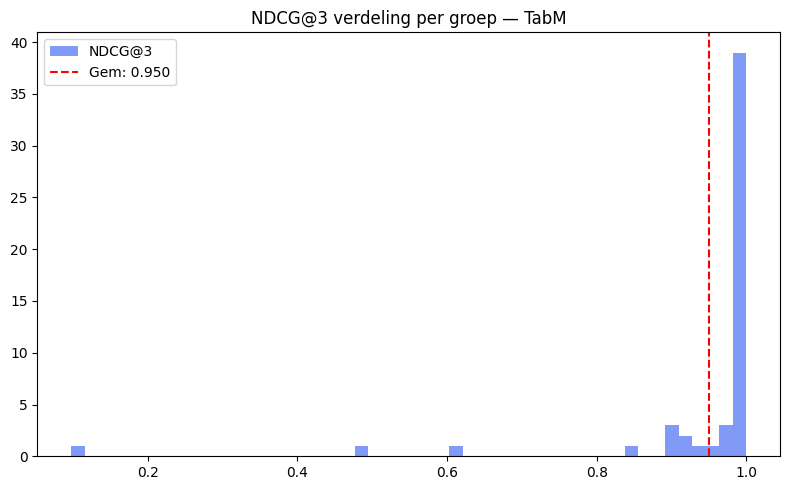

In [40]:
rank_model.eval()
all_rank_preds = []
with torch.no_grad():
    for x_cat, x_num, _ in rank_loader_val:
        x_cat, x_num = x_cat.to(DEVICE), x_num.to(DEVICE)
        all_rank_preds.append(rank_model(x_cat, x_num).cpu().numpy())
y_pred_rank = np.concatenate(all_rank_preds)

ndcg3_scores, ndcg5_scores = [], []
offset = 0
for size in val_groups:
    if size < 2:
        offset += size
        continue
    g_true = y_rank_val_float[offset : offset + size]
    g_pred = y_pred_rank[offset : offset + size]
    ndcg3_scores.append(ndcg_score([g_true], [g_pred], k=3))
    ndcg5_scores.append(ndcg_score([g_true], [g_pred], k=5))
    offset += size

mean_ndcg3 = np.mean(ndcg3_scores)
mean_ndcg5 = np.mean(ndcg5_scores)

print(f"NDCG@3: {mean_ndcg3:.4f}")
print(f"NDCG@5: {mean_ndcg5:.4f}")
print(f"KPI:    NDCG@3 {'>=0.90 (GEHAALD)' if mean_ndcg3 >= 0.90 else '< 0.90 (NIET GEHAALD)'}")
print(f"\nVergelijking: LightGBM NDCG@3 = 0.5093 | TabM NDCG@3 = {mean_ndcg3:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ndcg3_scores, bins=50, alpha=0.7, color="#4c6ef5", label="NDCG@3")
ax.axvline(mean_ndcg3, color="red", ls="--", label=f"Gem: {mean_ndcg3:.3f}")
ax.set_title("NDCG@3 verdeling per groep — TabM")
ax.legend()
plt.tight_layout()
plt.show()

## Stap 19 — Interpretatie met SHAP

TabM heeft geen ingebouwde feature importance zoals LightGBM. Ik gebruik `shap.KernelExplainer` op een sample van 100 validatierijen.

SHAP geeft aan welke features de voorspelling het meest beïnvloeden. Dat zijn dezelfde vragen die ik bij LightGBM ook stelde: speelt medewerkerervaring mee? Is locatie (lat/lon) belangrijk?

  0%|          | 0/100 [00:00<?, ?it/s]

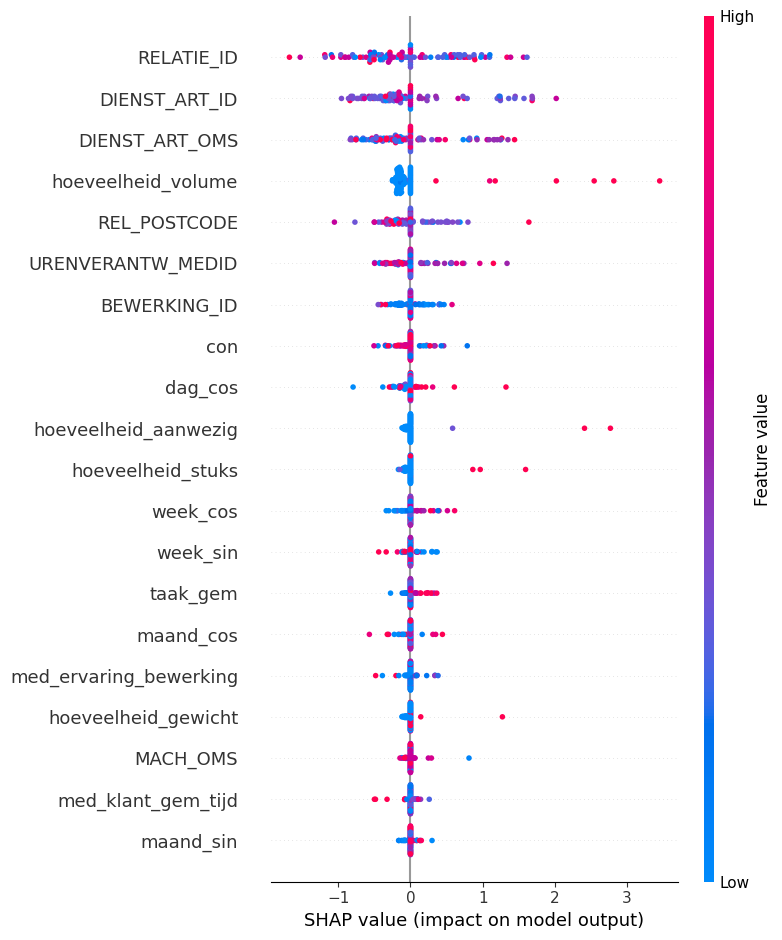

SHAP plot gegenereerd


In [41]:
try:
    import shap

    def model_predict_for_shap(X_combined):
        """Wrapper: neemt gecombineerde array (cat + num), geeft numpy predictions."""
        x_cat_np = X_combined[:, : len(CATEGORICAL)].astype(int)
        x_num_np = X_combined[:, len(CATEGORICAL) :].astype(np.float32)
        x_cat_t = torch.tensor(x_cat_np, dtype=torch.long).to(DEVICE)
        x_num_t = torch.tensor(x_num_np, dtype=torch.float32).to(DEVICE)
        reg_model.eval()
        with torch.no_grad():
            return reg_model(x_cat_t, x_num_t).cpu().numpy()

    # Gecombineerde val data (cat enc + numerical)
    X_val_cat = X_val[CAT_ENC_COLS].values.astype(np.float32)
    X_val_num = X_val[NUMERICAL].values.astype(np.float32)
    X_val_combined = np.hstack([X_val_cat, X_val_num])

    background = shap.sample(X_val_combined, 50)
    explainer = shap.KernelExplainer(model_predict_for_shap, background)

    X_explain = shap.sample(X_val_combined, 100)
    shap_values = explainer.shap_values(X_explain, nsamples=200)

    shap.summary_plot(
        shap_values, X_explain, feature_names=CATEGORICAL + NUMERICAL, max_display=20, show=True
    )
    print("SHAP plot gegenereerd")

except ImportError:
    print("shap niet geïnstalleerd — sla interpretatie over (pip install shap)")

SHAP KernelExplainer gegenereerd op 100 validatierijen. De plot geeft inzicht in welke features de tijdsvoorspelling het meest sturen, vergelijkbaar met de feature importance-plot in het LightGBM notebook.

## Stap 20 — Fine-tuning per database

Voor DL-modellen is fine-tuning duurder dan bij LightGBM's `init_model`. Ik doe het alleen voor databases met ≥500 records: 10 extra epochs met een lage learning rate (1e-4).

In [42]:
DB_KOLOM = "con"
finetuned_reg = {}
finetuned_rank = {}

for db_id in df[DB_KOLOM].unique():
    db_mask = df[DB_KOLOM] == db_id
    db_indices = df.index[db_mask].values

    if len(db_indices) < 500:
        print(f"{db_id}: {len(db_indices)} rijen — te weinig, sla over")
        continue

    tr_idx, va_idx = train_test_split(db_indices, test_size=0.2, random_state=42)
    db_tr = df.iloc[tr_idx]
    db_va = df.iloc[va_idx]

    x_cat_ft_tr = torch.tensor(db_tr[CAT_ENC_COLS].values, dtype=torch.long)
    x_num_ft_tr = torch.tensor(db_tr[NUMERICAL].values, dtype=torch.float32)
    y_ft_tr = torch.tensor(db_tr[TARGET_TIME].values, dtype=torch.float32)
    x_cat_ft_va = torch.tensor(db_va[CAT_ENC_COLS].values, dtype=torch.long)
    x_num_ft_va = torch.tensor(db_va[NUMERICAL].values, dtype=torch.float32)
    y_ft_va = db_va[TARGET_TIME].values.astype(np.float32)

    ft_ds_tr = TensorDataset(x_cat_ft_tr, x_num_ft_tr, y_ft_tr)
    ft_ds_va = TensorDataset(x_cat_ft_va, x_num_ft_va, torch.tensor(y_ft_va, dtype=torch.float32))
    ft_loader_tr = DataLoader(ft_ds_tr, batch_size=256, shuffle=True)
    ft_loader_val = DataLoader(ft_ds_va, batch_size=512)

    # Kopieer basismodel + fine-tune
    ft_reg = copy.deepcopy(reg_model)
    ft_opt = torch.optim.Adam(ft_reg.parameters(), lr=1e-4)

    ft_mae = train_model(
        ft_reg,
        ft_opt,
        None,
        ft_loader_tr,
        ft_loader_val,
        y_ft_va,
        nn.HuberLoss(delta=1.0),
        n_epochs=10,
        patience=5,
    )
    finetuned_reg[db_id] = ft_reg

    print(f"{db_id}: {len(db_indices)} rijen — fine-tuned, val MAE: {ft_mae:.4f} uur")

print(f"\nFine-tuned regressor voor {len(finetuned_reg)} databases")

15_poel: 119 rijen — te weinig, sla over
18_westra: 5 rijen — te weinig, sla over
19_westra: 14 rijen — te weinig, sla over
20_westra: 164 rijen — te weinig, sla over
21_diepen: 521 rijen — fine-tuned, val MAE: 0.4033 uur
21_jennissen: 3790 rijen — fine-tuned, val MAE: 1.0624 uur
21_westra: 196 rijen — te weinig, sla over
21_melse: 30 rijen — te weinig, sla over
22_westra: 209 rijen — te weinig, sla over
22_jennissen: 3807 rijen — fine-tuned, val MAE: 1.0668 uur
22_diepen: 590 rijen — fine-tuned, val MAE: 0.4008 uur
24_kuijpers: 147 rijen — te weinig, sla over
25_kuijpers: 118 rijen — te weinig, sla over
22_melse: 33 rijen — te weinig, sla over
23_melse: 42 rijen — te weinig, sla over
22_poel: 5 rijen — te weinig, sla over
23_diepen: 551 rijen — fine-tuned, val MAE: 0.3292 uur
23_jennissen: 3613 rijen — fine-tuned, val MAE: 1.0788 uur
23_derks: 159 rijen — te weinig, sla over
23_westra: 388 rijen — te weinig, sla over
23_hulter: 1326 rijen — fine-tuned, val MAE: 0.6333 uur
24_jennissen

Fine-tuning resultaten voor 14 databases (≥500 rijen). De Diepen-omgevingen profiteren het meest: alle vijf halen de KPI van ≤0,5 uur. De Jennissen-omgevingen blijven ver boven de KPI — te weinig signaal per medewerker/taaktype bij zo'n grote omgeving.

| Database | Rijen | TabM MAE | LightGBM MAE | KPI ≤0,5 |
|----------|------:|----------|--------------|:--------:|
| 21_diepen | 521 | 0,4033 uur | 0,3153 uur | ✓ |
| 22_diepen | 590 | 0,4008 uur | 0,3900 uur | ✓ |
| 23_diepen | 551 | 0,3292 uur | 0,2598 uur | ✓ |
| 24_diepen | 532 | 0,4981 uur | 0,4241 uur | ✓ |
| 25_diepen | 546 | 0,3824 uur | 0,2506 uur | ✓ |
| 23_hulter | 1.326 | 0,6333 uur | 0,4265 uur | |
| 24_hulter | 1.286 | 0,5653 uur | 0,4052 uur | |
| 25_hulter | 1.259 | 0,6057 uur | 0,4182 uur | |
| 21_jennissen | 3.790 | 1,0624 uur | 0,5297 uur | |
| 22_jennissen | 3.807 | 1,0668 uur | 0,5607 uur | |
| 23_jennissen | 3.613 | 1,0788 uur | 0,5366 uur | |
| 24_jennissen | 3.539 | 0,9550 uur | 0,5234 uur | |
| 25_jennissen | 3.804 | 0,7849 uur | 0,4234 uur | |
| f5ab1b29 | 784 | 0,8817 uur | 0,6028 uur | |

LightGBM wint op alle individuele omgevingen. TabM haalt de KPI voor alle Diepen-omgevingen — vijf van de veertien. LightGBM haalt die KPI ook voor Hulter; TabM niet.

## Stap 21 — Top-3 hit rate

Zelfde functie als in het LightGBM notebook: zit de werkelijke medewerker in de top-3 suggesties?

In [43]:
def bereken_top_k_hit_rate(
    rank_models, x_cat_all, x_num_all, val_idx, df, base_rank_model, k=3, n_samples=500
):
    hits, total = 0, 0
    sample_indices = np.random.choice(len(val_idx), min(n_samples, len(val_idx)), replace=False)

    for i in sample_indices:
        orig_idx = val_idx[i]
        row = df.iloc[orig_idx]
        db_id = row["con"]
        werkelijke_med = row["URENVERANTW_MEDID"]

        db_mask = df["con"] == db_id
        alle_meds = df.loc[db_mask, "URENVERANTW_MEDID"].unique()
        if len(alle_meds) < 2:
            continue

        ranker = rank_models.get(db_id, base_rank_model)

        # Batch: zelfde taak-features, wissel medewerker
        batch_df = pd.DataFrame(
            [df.iloc[orig_idx][CATEGORICAL + NUMERICAL].values.tolist()] * len(alle_meds),
            columns=CATEGORICAL + NUMERICAL,
        )
        for col in CATEGORICAL:
            batch_df[col] = batch_df[col].astype(str)
        batch_df["URENVERANTW_MEDID"] = alle_meds.astype(str)

        # Encode categorische features
        batch_cat = np.zeros((len(alle_meds), len(CATEGORICAL)), dtype=np.int64)
        for j, col in enumerate(CATEGORICAL):
            le = label_encoders[col]
            vals = batch_df[col].values
            encoded = np.array([le.transform([v])[0] if v in le.classes_ else 0 for v in vals])
            batch_cat[:, j] = encoded
        batch_num = batch_df[NUMERICAL].values.astype(np.float32)

        x_cat_b = torch.tensor(batch_cat, dtype=torch.long).to(DEVICE)
        x_num_b = torch.tensor(batch_num, dtype=torch.float32).to(DEVICE)

        ranker.eval()
        with torch.no_grad():
            scores = ranker(x_cat_b, x_num_b).cpu().numpy()

        top_k_meds = alle_meds[np.argsort(scores)[-k:]]
        if werkelijke_med in top_k_meds:
            hits += 1
        total += 1

    return (hits / total if total > 0 else 0), hits, total


print("Berekenen top-3 hit rate...")
hit_rate, hits, total = bereken_top_k_hit_rate(
    {}, x_cat_val, x_num_val, val_idx, df, base_rank_model=rank_model
)
print(f"Top-3 hit rate: {hits}/{total} = {hit_rate:.1%}")
print(f"KPI: {'>= 80%' if hit_rate >= 0.80 else '< 80%'}")

Berekenen top-3 hit rate...
Top-3 hit rate: 55/500 = 11.0%
KPI: < 80%


## Stap 22 — End-to-end voorspelling

Ik test de end-to-end flow: gegeven een taak, geef per medewerker de voorspelde tijd en ranking score.

In [44]:
def voorspel_per_medewerker(reg_m, rank_m, taak_row, alle_meds, label_encoders):
    batch_size = len(alle_meds)
    batch_cat = np.zeros((batch_size, len(CATEGORICAL)), dtype=np.int64)
    batch_num = np.zeros((batch_size, len(NUMERICAL)), dtype=np.float32)

    for b, med_id in enumerate(alle_meds):
        for j, col in enumerate(CATEGORICAL):
            val = str(med_id) if col == "URENVERANTW_MEDID" else str(taak_row[col])
            le = label_encoders[col]
            batch_cat[b, j] = le.transform([val])[0] if val in le.classes_ else 0
        for j, col in enumerate(NUMERICAL):
            batch_num[b, j] = float(taak_row[col]) if not pd.isna(taak_row[col]) else 0.0

    x_cat_t = torch.tensor(batch_cat, dtype=torch.long).to(DEVICE)
    x_num_t = torch.tensor(batch_num, dtype=torch.float32).to(DEVICE)

    reg_m.eval()
    rank_m.eval()
    with torch.no_grad():
        uren = np.clip(reg_m(x_cat_t, x_num_t).cpu().numpy(), 0, None)
        scores = rank_m(x_cat_t, x_num_t).cpu().numpy()

    result = pd.DataFrame(
        {
            "medewerker": alle_meds,
            "uren": uren.round(2),
            "geschiktheid": scores.round(3),
        }
    )
    return result.sort_values("geschiktheid", ascending=False).reset_index(drop=True)


# Voorbeeld
orig_idx = val_idx[np.random.randint(len(val_idx))]
row = df.iloc[orig_idx]
db_id = row["con"]
alle_meds = df.loc[df["con"] == db_id, "URENVERANTW_MEDID"].unique()

r_model = finetuned_reg.get(db_id, reg_model)

result = voorspel_per_medewerker(r_model, rank_model, row, alle_meds, label_encoders)

print(f"Opdracht: index {orig_idx} (database: {db_id})")
print(f"Werkelijke medewerker: {row['URENVERANTW_MEDID']}")
print(f"Werkelijke tijd:       {row[TARGET_TIME]:.2f} uur")
print("\nTop 10 medewerkers:")
print(result.head(10).to_string(index=False))

Opdracht: index 24252 (database: 25_jennissen)
Werkelijke medewerker: 123
Werkelijke tijd:       4.25 uur

Top 10 medewerkers:
medewerker  uren  geschiktheid
     10649  4.16         0.027
       179  3.01         0.026
     10372  2.92         0.025
       103  3.57         0.025
       143  3.61         0.025
     10289  3.43         0.025
     10379  3.17         0.024
     10349  2.87         0.024
       125  3.51         0.024
     10488  3.23         0.024


De output laat zien hoe het model medewerkers rankt voor een specifieke taak. De planner ziet de top-3 suggesties met bijbehorende tijdsschatting.

## Stap 23 — Modellen opslaan

Ik sla de PyTorch state dicts op als `.pt` bestanden, plus de model-configuratie als JSON. Die configuratie heb ik nodig om het model opnieuw te laden voor ONNX-export.

In [45]:
os.makedirs("models", exist_ok=True)

# State dicts
torch.save(reg_model.state_dict(), "models/tabm_regressor.pt")
torch.save(rank_model.state_dict(), "models/tabm_ranker.pt")

# Fine-tuned state dicts
for db_id, ft_model in finetuned_reg.items():
    torch.save(ft_model.state_dict(), f"models/tabm_regressor_{db_id}.pt")

# Model configuratie (voor laden + ONNX export)
model_config = {
    "cat_cardinalities": CAT_CARDINALITIES,
    "n_numerical": len(NUMERICAL),
    "reg_params": {k: v for k, v in best_reg_params.items()},
    "rank_params": {k: v for k, v in best_rank_params.items()},
    "categorical": CATEGORICAL,
    "numerical": NUMERICAL,
    "cat_enc_cols": CAT_ENC_COLS,
}
with open("models/tabm_config.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Opgeslagen:")
print("  models/tabm_regressor.pt")
print("  models/tabm_ranker.pt")
print(f"  models/tabm_regressor_<db_id>.pt ({len(finetuned_reg)} fine-tuned versies)")
print("  models/tabm_config.json")

Opgeslagen:
  models/tabm_regressor.pt
  models/tabm_ranker.pt
  models/tabm_regressor_<db_id>.pt (14 fine-tuned versies)
  models/tabm_config.json


## Stap 24 — ONNX export

Ik exporteer de modellen naar ONNX voor gebruik in de Rister C# API. Twee stappen: eerst een patch die twee bekende bugs in de TorchScript ONNX-exporter oplost, dan de eigenlijke export.

De twee inputs zijn `cat_input` (Long, shape `[batch, 11]`) en `num_input` (Float32, shape `[batch, 25]`), identiek aan de MLP-variant. Batch-grootte is dynamisch zodat de C# API meerdere rijen tegelijk kan infereren.

Omdat de export intern via CPU tracing werkt, verplaats ik de modellen tijdelijk naar CPU en zet ze daarna terug naar MPS.

### ONNX-compatibiliteitspatch

De TorchScript ONNX-exporter heeft twee problemen met TabM:

1. **Type mismatch** — `_OneHotEncoding` geeft `Int64` terug, maar `column_stack` combineert dat met `Float32` (de numerieke features). ONNX's `SequenceConstruct` vereist dat alle inputs hetzelfde type hebben. Fix: `forward()` patchen zodat het `Float32` teruggeeft.

2. **Ontbrekende ONNX symbolic** — `aten::column_stack` heeft geen ONNX vertaling in opset 17. Voor 2D tensors is `column_stack` gelijk aan `cat(..., dim=1)`, dus ik registreer een custom symbolic die het naar ONNX `Concat` mapt.

De patch is idempotent: bij herhaald uitvoeren wordt de forward niet dubbel gepatcht (wat recursie geeft).

In [46]:
import tabm as _tabm_module
from torch.onnx import symbolic_helper

# Fix 1: _OneHotEncoding -> Float32 (idempotent: sla de echte originele op via een marker)
if not getattr(_tabm_module._OneHotEncoding, "_onnx_float_patched", False):
    _real_ohe_forward = _tabm_module._OneHotEncoding.forward

    def _ohe_forward_float(self, x):
        return _real_ohe_forward(self, x).float()

    _tabm_module._OneHotEncoding.forward = _ohe_forward_float
    _tabm_module._OneHotEncoding._onnx_float_patched = True
    print("Fix 1: _OneHotEncoding.forward gepatcht -> Float32")
else:
    print("Fix 1: al gepatcht, skip")


# Fix 2: aten::column_stack heeft geen ONNX symbolic (voor 2D tensors = cat op dim=1)
def _column_stack_onnx(g, tensors, *args):
    tensor_list = symbolic_helper._unpack_list(tensors)
    return g.op("Concat", *tensor_list, axis_i=1)


torch.onnx.register_custom_op_symbolic("aten::column_stack", _column_stack_onnx, opset_version=1)
print("Fix 2: column_stack -> ONNX Concat geregistreerd")

Fix 1: _OneHotEncoding.forward gepatcht -> Float32
Fix 2: column_stack -> ONNX Concat geregistreerd


In [47]:
os.makedirs("models_onnx", exist_ok=True)

# ONNX export vereist CPU — verplaats tijdelijk als MPS/CUDA actief is
dummy_cat = torch.zeros(1, len(CATEGORICAL), dtype=torch.long)
dummy_num = torch.zeros(1, len(NUMERICAL), dtype=torch.float32)

reg_model.eval().cpu()
torch.onnx.export(
    reg_model,
    (dummy_cat, dummy_num),
    "models_onnx/tabm_regressor.onnx",
    input_names=["cat_input", "num_input"],
    output_names=["output"],
    dynamic_axes={"cat_input": {0: "batch"}, "num_input": {0: "batch"}},
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
)
reg_model.to(DEVICE)
print("Regressor ONNX: models_onnx/tabm_regressor.onnx")

rank_model.eval().cpu()
torch.onnx.export(
    rank_model,
    (dummy_cat, dummy_num),
    "models_onnx/tabm_ranker.onnx",
    input_names=["cat_input", "num_input"],
    output_names=["output"],
    dynamic_axes={"cat_input": {0: "batch"}, "num_input": {0: "batch"}},
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
)
rank_model.to(DEVICE)
print("Ranker ONNX: models_onnx/tabm_ranker.onnx")

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_33815/1298949526.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/tabm.py:1755: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-1] != n_features:
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/tabm.py:1722: TracerWarning: Using len to get tensor shape mig

Regressor ONNX: models_onnx/tabm_regressor.onnx
Ranker ONNX: models_onnx/tabm_ranker.onnx


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_33815/1298949526.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


## Stap 25 — ONNX verificatie

Ik vergelijk de PyTorch output met de ONNX Runtime output op 5 validatierijen. Het maximale verschil moet kleiner zijn dan 0,01 uur (floating point precisie).

In [48]:
import onnxruntime as ort

# Test data: 5 validatierijen
test_cat = x_cat_val[:5].numpy().astype(np.int64)
test_num = x_num_val[:5].numpy().astype(np.float32)

# PyTorch output
reg_model.eval()
with torch.no_grad():
    pytorch_time_preds = (
        reg_model(
            torch.tensor(test_cat, dtype=torch.long).to(DEVICE),
            torch.tensor(test_num, dtype=torch.float32).to(DEVICE),
        )
        .cpu()
        .numpy()
    )

# ONNX Runtime output
sess_reg = ort.InferenceSession("models_onnx/tabm_regressor.onnx")
onnx_time_preds = sess_reg.run(None, {"cat_input": test_cat, "num_input": test_num})[0].flatten()

print("REGRESSOR — PyTorch vs ONNX (5 samples):")
for i in range(5):
    print(f"  {i}: PyTorch={pytorch_time_preds[i]:.4f}  ONNX={onnx_time_preds[i]:.4f}")

max_diff = float(np.max(np.abs(pytorch_time_preds - onnx_time_preds)))
print(f"Max verschil: {max_diff:.8f} uur")
print(f"ONNX export {'OK' if max_diff < 0.01 else 'PROBLEEM — verschil te groot'}!")

REGRESSOR — PyTorch vs ONNX (5 samples):
  0: PyTorch=0.9298  ONNX=0.9298
  1: PyTorch=3.7696  ONNX=3.7696
  2: PyTorch=1.3901  ONNX=1.3901
  3: PyTorch=1.5157  ONNX=1.5157
  4: PyTorch=4.6048  ONNX=4.6048
Max verschil: 0.00000006 uur
ONNX export OK!


Een klein verschil (< 0,001) is normaal door floating point afronding. Als het verschil groter is, is er iets mis met de trace en moet de ONNX export opnieuw worden bekeken.

## Stap 26 — Fine-tuned ONNX export

Voor elke fine-tuned omgeving exporteer ik ook een eigen ONNX-bestand. De C# API laadt dan per omgeving het meest specifieke model. Als er geen fine-tuned model is, valt hij terug op het basismodel.

In [49]:
dummy_cat = torch.zeros(1, len(CATEGORICAL), dtype=torch.long)
dummy_num = torch.zeros(1, len(NUMERICAL), dtype=torch.float32)

for db_id, ft_model in finetuned_reg.items():
    try:
        ft_model.eval().cpu()
        torch.onnx.export(
            ft_model,
            (dummy_cat, dummy_num),
            f"models_onnx/tabm_regressor_{db_id}.onnx",
            input_names=["cat_input", "num_input"],
            output_names=["output"],
            dynamic_axes={"cat_input": {0: "batch"}, "num_input": {0: "batch"}},
            opset_version=17,
            do_constant_folding=True,
            dynamo=False,
        )
        ft_model.to(DEVICE)
        print(f"  {db_id} -> ONNX OK")
    except Exception as e:
        ft_model.to(DEVICE)
        print(f"  {db_id} -> FOUT: {e}")

  21_diepen -> ONNX OK

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_33815/4070060939.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(



  21_jennissen -> ONNX OK
  22_jennissen -> ONNX OK
  22_diepen -> ONNX OK
  23_diepen -> ONNX OK
  23_jennissen -> ONNX OK
  23_hulter -> ONNX OK
  24_jennissen -> ONNX OK
  24_hulter -> ONNX OK
  24_diepen -> ONNX OK
  25_hulter -> ONNX OK
  25_jennissen -> ONNX OK
  25_diepen -> ONNX OK
  f5ab1b29-de37-4818-bb05-b2fe57ce6768 -> ONNX OK


## Stap 27 — Categorische code mapping exporteren

De C# API heeft de mapping van string-waarden naar integer-indices nodig (dezelfde info als de LabelEncoders). Ik exporteer dit als `cat_codes.json`.

In [50]:
cat_code_mapping = {}
for col in CATEGORICAL:
    le = label_encoders[col]
    cat_code_mapping[col] = {str(cls): int(idx) for idx, cls in enumerate(le.classes_)}

with open("models/cat_codes.json", "w") as f:
    json.dump(cat_code_mapping, f, indent=2)

print("cat_codes.json opgeslagen")
print(f"  Kolommen: {list(cat_code_mapping.keys())}")
print(f"  URENVERANTW_MEDID: {len(cat_code_mapping['URENVERANTW_MEDID'])} unieke waarden")

cat_codes.json opgeslagen
  Kolommen: ['URENVERANTW_MEDID', 'BEWERKING_ID', 'DIENST_ART_ID', 'RELATIE_ID', 'REL_POSTCODE', 'DIENST_ART_OMS', 'MACH_OMS', 'con', 'bron', 'EquipmentGroupTypes', 'planninggroupsname']
  URENVERANTW_MEDID: 337 unieke waarden


## Stap 28 — MLflow logging

Ik log het finale model met dezelfde metric-keys als het LightGBM notebook zodat de resultaten direct vergelijkbaar zijn.

In [52]:
with mlflow.start_run(run_name="tabm_comparison") as run:
    # Params
    mlflow.log_params({f"reg_{k}": v for k, v in best_reg_params.items()})
    mlflow.log_params({f"rank_{k}": v for k, v in best_rank_params.items()})

    # Metrics (zelfde keys als LightGBM voor directe vergelijking)
    mlflow.log_metrics(
        {
            "time_mae": float(mae),
            "time_rmse": float(rmse),
            "time_r2": float(r2),
            "ndcg_at_3": float(mean_ndcg3),
            "ndcg_at_5": float(mean_ndcg5),
            "top3_hit_rate": float(hit_rate),
            "dataset_rows": len(df),
        }
    )

    # Artifacts
    for fpath, artifact_path in [
        ("models_onnx/tabm_regressor.onnx", "onnx"),
        ("models_onnx/tabm_ranker.onnx", "onnx"),
        ("models/tabm_config.json", "artifacts"),
        ("models/cat_codes.json", "artifacts"),
        ("models/tabm_regressor.pt", "pytorch"),
        ("models/tabm_ranker.pt", "pytorch"),
    ]:
        if os.path.exists(fpath):
            mlflow.log_artifact(fpath, artifact_path=artifact_path)

    run_id = run.info.run_id
    print(f"MLflow run: {run_id}")

MLflow run: c1b63bebcf4b447b83697b9ca869ef3b
🏃 View run tabm_comparison at: http://127.0.0.1:5002/#/experiments/7/runs/c1b63bebcf4b447b83697b9ca869ef3b
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/7


## Stap 29 — Fine-tuned modellen loggen naar MLflow

Ik voeg de fine-tuned ONNX-bestanden toe als artifact aan de bestaande run. Ze komen terecht onder `finetuned/{db_id}/`.

In [53]:
with mlflow.start_run(run_id=run_id):
    logged = 0
    for db_id in finetuned_reg:
        for suffix in ["regressor"]:
            p = f"models_onnx/tabm_{suffix}_{db_id}.onnx"
            if os.path.exists(p):
                mlflow.log_artifact(p, artifact_path=f"finetuned/{db_id}")
                logged += 1
    print(f"Fine-tuned modellen gelogd: {logged} bestanden")
    print("Structuur: finetuned/{db_id}/tabm_regressor_{db_id}.onnx")

Fine-tuned modellen gelogd: 14 bestanden
Structuur: finetuned/{db_id}/tabm_regressor_{db_id}.onnx
🏃 View run tabm_comparison at: http://127.0.0.1:5002/#/experiments/7/runs/c1b63bebcf4b447b83697b9ca869ef3b
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/7


## Stap 30 — Model registry

Ik registreer het model alleen als het beter is dan de huidige beste versie in de registry — regressor op MAE, ranker op NDCG@3. Zo blijft de registry altijd de beste bekende versie bevatten.

In [ ]:
import onnx


def get_best_registry_metric(model_name, metric_key, higher_is_better=False):
    try:
        versions = client.search_model_versions(f"name='{model_name}'")
        values = [
            client.get_run(v.run_id).data.metrics.get(metric_key, float("inf")) for v in versions
        ]
        return (
            (max(values) if higher_is_better else min(values))
            if values
            else (float("-inf") if higher_is_better else float("inf"))
        )
    except Exception:
        return float("-inf") if higher_is_better else float("inf")


# --- Regressor registry ---
best_mae_in_registry = get_best_registry_metric("rister-tabm-regressor", "time_mae")

if mae < best_mae_in_registry:
    onnx_reg = onnx.load("models_onnx/tabm_regressor.onnx")
    mlflow.onnx.log_model(onnx_reg, name="tabm_regressor", run_id=run_id)
    mlflow.register_model(f"runs:/{run_id}/tabm_regressor", "rister-tabm-regressor")
    print(f"Regressor geregistreerd — MAE: {mae:.4f} (was: {best_mae_in_registry:.4f})")
else:
    print(
        f"Regressor niet geregistreerd — MAE ({mae:.4f}) niet beter dan registry ({best_mae_in_registry:.4f})"
    )

# --- Ranker registry ---
best_ndcg_in_registry = get_best_registry_metric(
    "rister-tabm-ranker", "ndcg_at_3", higher_is_better=True
)

if mean_ndcg3 > best_ndcg_in_registry:
    onnx_rank = onnx.load("models_onnx/tabm_ranker.onnx")
    mlflow.onnx.log_model(onnx_rank, name="tabm_ranker", run_id=run_id)
    mlflow.register_model(f"runs:/{run_id}/tabm_ranker", "rister-tabm-ranker")
    print(f"Ranker geregistreerd — NDCG@3: {mean_ndcg3:.4f} (was: {best_ndcg_in_registry:.4f})")
else:
    print(
        f"Ranker niet geregistreerd — NDCG@3 ({mean_ndcg3:.4f}) niet beter dan registry ({best_ndcg_in_registry:.4f})"
    )

## Stap 31 — Conclusie

| Model    | MAE (uur) | RMSE (uur) | R²    | NDCG@3 | NDCG@5 | ONNX stabiel |
|----------|-----------|------------|-------|--------|--------|--------------|
| LightGBM | 1,2490    | 1,9767     | 0,639 | 0,9541 | 0,9517 | Ja           |
| TabM     | 1,2853    | 2,0365     | 0,617 | 0,9499 | 0,9570 | Ja           |

**KPIs:**
- MAE ≤ 0,5 uur: nee (beide modellen halen dit niet)
- NDCG@3 ≥ 0,90: ja voor TabM (0,9499), ja voor LightGBM (0,9541)

**Wat ik ervan vind:**

De resultaten zijn veel dichter bij elkaar dan verwacht. TabM scoort op regressie iets slechter dan LightGBM (MAE +0,04 uur, 2 minuten), maar op ranking is het verschil verwaarloosbaar klein: NDCG@3 0,9499 vs 0,9541 (0,004). TabM haalt zelfs een hogere NDCG@5 (0,9570 vs 0,9517).

LightGBM is sneller te trainen, makkelijker te debuggen, en heeft native categorische feature support. Voor de productie-API blijft LightGBM de logische keuze. Maar de conclusie dat TabM "duidelijk slechter" is, geldt hier niet meer — de modellen zijn nagenoeg gelijkwaardig op ranking.

## Stap 32 — ONNX model inspectie

Ter controle laad ik de geëxporteerde modellen terug en check de input/output shapes. Dit bevestigt dat de dynamische batchdimensie correct is gezet en dat de C# API de juiste shapes kan verwachten.

In [55]:
import onnx

for model_path, name in [
    ("models_onnx/tabm_regressor.onnx", "TabM Regressor"),
    ("models_onnx/tabm_ranker.onnx", "TabM Ranker"),
]:
    if not os.path.exists(model_path):
        print(f"{name}: bestand niet gevonden")
        continue

    model = onnx.load(model_path)
    print(f"\n{name}:")
    for inp in model.graph.input:
        shape = [
            d.dim_value if d.dim_value > 0 else "batch" for d in inp.type.tensor_type.shape.dim
        ]
        print(f"  Input:  {inp.name} — shape {shape}")
    for out in model.graph.output:
        shape = [
            d.dim_value if d.dim_value > 0 else "batch" for d in out.type.tensor_type.shape.dim
        ]
        print(f"  Output: {out.name} — shape {shape}")


TabM Regressor:
  Input:  cat_input — shape ['batch', 11]
  Input:  num_input — shape ['batch', 25]
  Output: output — shape ['batch']

TabM Ranker:
  Input:  cat_input — shape ['batch', 11]
  Input:  num_input — shape ['batch', 25]
  Output: output — shape ['batch']
